# Segmentação de Imagens com U-Net no Dataset Oxford-IIIT Pet

In [ ]:
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torchmetrics
import numpy as np
import torch
import time

## Preparação dos Dados e Treinamento do Modelo

In [20]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_DIR = "./data"
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_CLASSES = 3
LEARNING_RATE = 0.001
NUM_EPOCHS = 20

NUM_TRAIN_SAMPLES = 1000
NUM_VAL_SAMPLES = 200

image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

target_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
])

def process_target(target):
    target = torch.squeeze(target)
    target = target - 1
    return target.long()

full_dataset = datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=image_transform,
    target_transform=lambda t: process_target(target_transform(t))
)

indices = torch.randperm(len(full_dataset)).tolist()
train_dataset = Subset(full_dataset, indices[:NUM_TRAIN_SAMPLES])
val_dataset = Subset(full_dataset, indices[NUM_TRAIN_SAMPLES:NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=NUM_CLASSES, features=[64, 128]):
        super(SimpleUNet, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]
            
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](concat_skip)

        return self.final_conv(x)
    
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    model.to(DEVICE)
    best_loss = float('inf')
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        model.train()
        running_loss = 0.0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)
            if isinstance(outputs, dict):
                outputs = outputs['out']
            
            loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)
                
                outputs = model(images)
                if isinstance(outputs, dict):
                    outputs = outputs['out']

                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)

        val_loss = val_loss / len(val_loader.dataset)
        
        end_time = time.time()
        epoch_duration = end_time - start_time
        
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Duração: {epoch_duration:.2f}s - "
              f"Train Loss: {epoch_loss:.4f} - "
              f"Val Loss: {val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), f"{model.__class__.__name__}_best.pth")
            print(f"  -> Modelo salvo com a melhor val loss: {best_loss:.4f}")
            
    return model

In [ ]:
unet_model = SimpleUNet(in_channels=3, out_channels=NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(unet_model.parameters(), lr=LEARNING_RATE)
trained_unet = train_model(unet_model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS)

Epoch 1/20 [Val]: 100%|██████████| 7/7 [00:02<00:00,  2.65it/s]


Epoch 1/20 - Duração: 20.25s - Train Loss: 0.8627 - Val Loss: 0.9541
  -> Modelo salvo com a melhor val loss: 0.9541


Epoch 2/20 [Val]: 100%|██████████| 7/7 [00:01<00:00,  5.48it/s]


Epoch 2/20 - Duração: 12.13s - Train Loss: 0.6908 - Val Loss: 0.7641
  -> Modelo salvo com a melhor val loss: 0.7641


Epoch 3/20 [Val]: 100%|██████████| 7/7 [00:01<00:00,  5.44it/s]


...

Epoch 18/20 - Duração: 11.76s - Train Loss: 0.4176 - Val Loss: 0.5328


Epoch 19/20 [Val]: 100%|██████████| 7/7 [00:01<00:00,  5.88it/s]


Epoch 19/20 - Duração: 11.67s - Train Loss: 0.4157 - Val Loss: 0.4724


Epoch 20/20 [Val]: 100%|██████████| 7/7 [00:01<00:00,  5.80it/s]

Epoch 20/20 - Duração: 11.78s - Train Loss: 0.3987 - Val Loss: 0.4425
  -> Modelo salvo com a melhor val loss: 0.4425


## Avaliação de Performance e Visualização


Carregando o melhor modelo salvo...

Calculando métricas no conjunto de validação...


Avaliando: 100%|██████████| 7/7 [00:01<00:00,  4.65it/s]


Mean IoU (mIoU): 0.6016
Pixel Accuracy: 0.7083


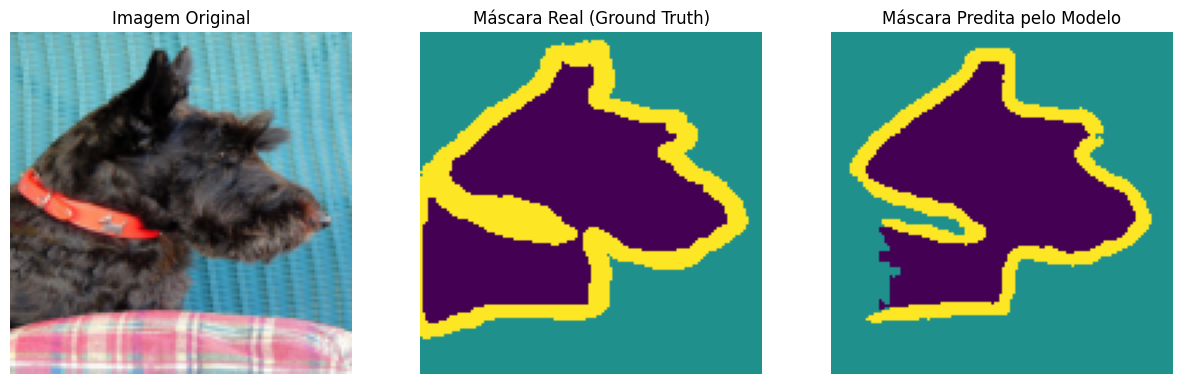

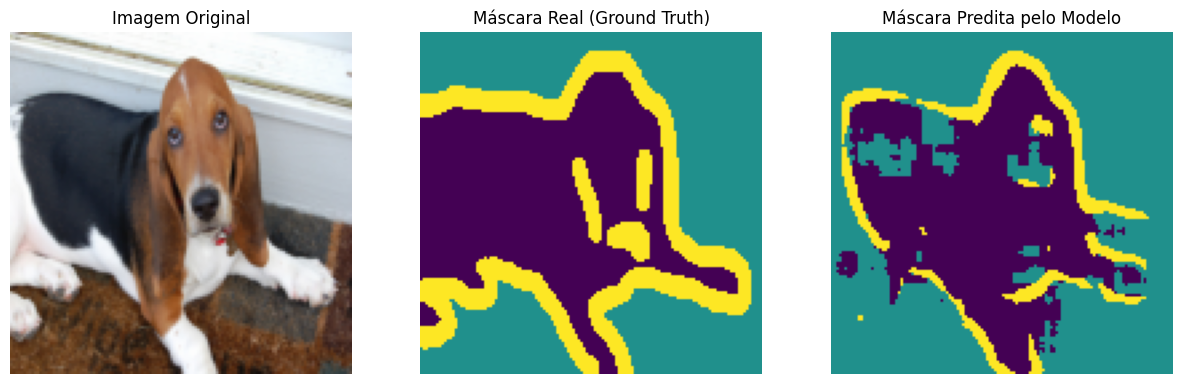

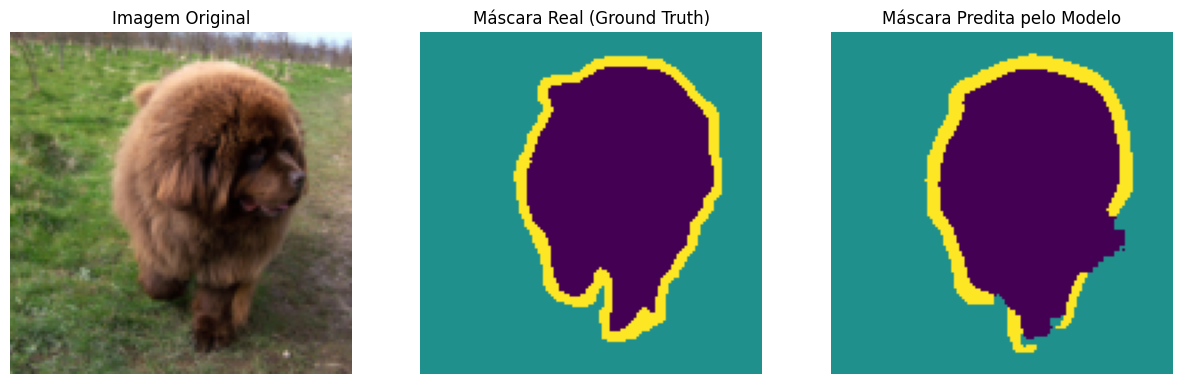

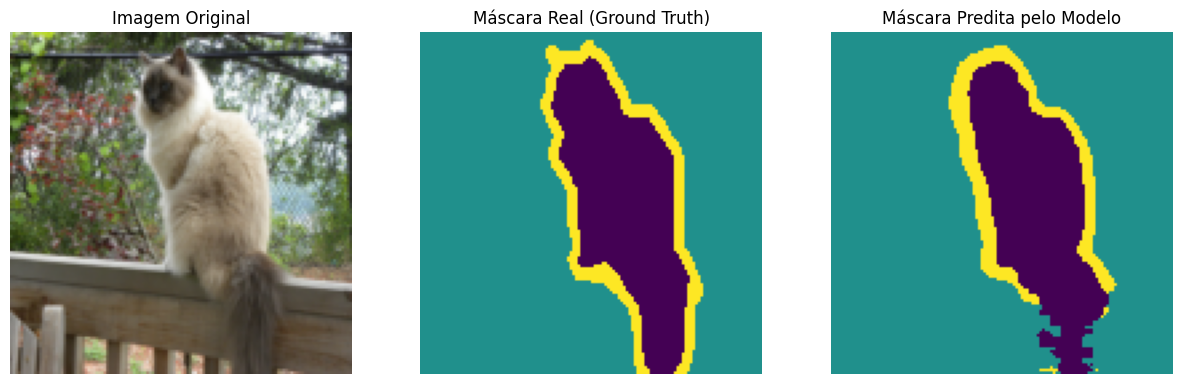

In [ ]:
def check_metrics(loader, model):
    """
    Calcula e imprime a acurácia e a média de IoU (Intersection over Union)
    para um dado dataloader e modelo.
    """
    print("\nCalculando métricas no conjunto de validação...")
    
    jaccard = torchmetrics.JaccardIndex(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)
    
    model.eval()
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Avaliando"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            
            preds = model(x)
            preds_classes = torch.argmax(preds, dim=1)
            
            jaccard.update(preds_classes, y)
            accuracy.update(preds_classes, y)

    final_iou = jaccard.compute()
    final_acc = accuracy.compute()
    
    print(f"Mean IoU (mIoU): {final_iou.item():.4f}")
    print(f"Pixel Accuracy: {final_acc.item():.4f}")
    
    jaccard.reset()
    accuracy.reset()


def plot_predictions(loader, model, num_images=5):
    """
    Plota a imagem original, a máscara real (ground truth) e a máscara predita
    para um número de exemplos do dataloader, pulando o primeiro exemplo.
    """
    model.eval()
    
    images, masks = next(iter(loader))
    images, masks = images.to(DEVICE), masks.to(DEVICE)

    with torch.no_grad():
        preds = torch.argmax(model(images), dim=1)

    images = images.cpu().numpy()
    masks = masks.cpu().numpy()
    preds = preds.cpu().numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i in range(2, min(len(images), num_images + 1)):
        img_display = images[i].transpose(1, 2, 0)
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(img_display)
        plt.title("Imagem Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(masks[i], cmap='viridis')
        plt.title("Máscara Real (Ground Truth)")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(preds[i], cmap='viridis')
        plt.title("Máscara Predita pelo Modelo")
        plt.axis("off")

        plt.show()

print("\nCarregando o melhor modelo salvo...")
model_to_evaluate = SimpleUNet(in_channels=3, out_channels=NUM_CLASSES)
model_to_evaluate.load_state_dict(torch.load("SimpleUNet_best.pth"))
model_to_evaluate.to(DEVICE)

check_metrics(val_loader, model_to_evaluate)
plot_predictions(val_loader, model_to_evaluate, num_images=5)